In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [5]:
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\BR\Hate_Crimes_2017-2025.csv")

In [7]:
df

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District
0,Jan,2017-241137,01/01/2017 12:00:00 AM,Sun,0,1,0,1,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0
1,Feb,2017-580344,02/01/2017 12:00:00 AM,Wed,0,1,0,1,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0
2,Mar,2017-800291,03/21/2017 12:00:00 AM,Tue,0,0,0,0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0
3,Apr,2017-1021534,04/12/2017 12:00:00 AM,Wed,0,0,0,0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0
4,May,2017-1351550,05/15/2017 12:00:00 AM,Mon,1,0,1,2,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Feb,2025-9004370,02/27/2025 12:00:00 AM,Thu,0,1,0,1,White/Non-Hispanic,Harassment,Bar/Nightclub,Anti-Lesbian/Bisexual/Transgender (Mixed Group),78745.0,David,3.0
262,Mar,2025-601075,03/02/2025 12:00:00 AM,Sun,1,0,0,1,White/Non-Hispanic,Assault,Hwy/Road/Alley/Street/Sidewalk,Anti-White/Anti-Hispanic or Latino,78741.0,Henry,3.0
263,Mar,2025-640147,03/05/2025 12:00:00 AM,Wed,0,1,0,1,White/Non-Hispanic,Assault,Hwy/Road/Alley/Street/Sidewalk,Anti-Black or African American,78701.0,George,9.0
264,Mar,2025-9004907,03/07/2025 12:00:00 AM,Fri,0,1,0,2,White/Non-Hispanic,Harassment,Residence/Home,Anti-Gay (Male),78705.0,Baker,9.0


In [ ]:
##How has the number of hate crime incidents changed from 2017 to 2025?

In [18]:
df.head()

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District
0,Jan,2017-241137,01/01/2017 12:00:00 AM,Sun,0,1,0,1,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0
1,Feb,2017-580344,02/01/2017 12:00:00 AM,Wed,0,1,0,1,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0
2,Mar,2017-800291,03/21/2017 12:00:00 AM,Tue,0,0,0,0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0
3,Apr,2017-1021534,04/12/2017 12:00:00 AM,Wed,0,0,0,0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0
4,May,2017-1351550,05/15/2017 12:00:00 AM,Mon,1,0,1,2,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0


In [22]:
df["Year"] = pd.to_datetime(df["Date of Incident"]).dt.year

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21956\333487479.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Year"] = pd.to_datetime(df["Date of Incident"]).dt.year


In [30]:
yearly_incidents = df.groupby("Year")["Incident Number"].count()

<Axes: title={'center': 'Trend of Crimes(Yearly)'}, xlabel='Year', ylabel='Number Of Incidents'>

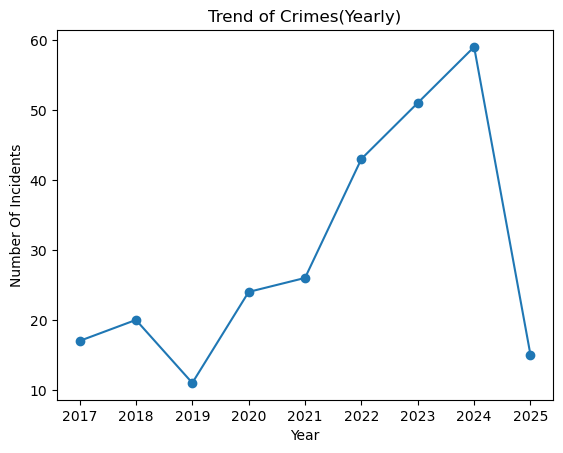

In [36]:
yearly_incidents.plot(xlabel = "Year", ylabel = "Number Of Incidents", marker = 'o', title = "Trend of Crimes(Yearly)")

In [44]:
yearly_incidents.reset_index(name = 'Crime Count')

,Year,Crime Count
0,2017,17
1,2018,20
2,2019,11
3,2020,24
4,2021,26
5,2022,43
6,2023,51
7,2024,59
8,2025,15


In [ ]:
##Are there particular months or days of the week with higher hate crime occurrences?

In [67]:
highest_crime_days = df.groupby('Day of Week')["Incident Number"].count().sort_values(ascending =  False).head(2)
highest_crime_days

Day of Week
Sat    50
Sun    50
Name: Incident Number, dtype: int64

In [69]:
"""It's noticed that the highest days with crimes are saturday and sunday, meaning more crimes are committed during the weekends"""

"It's noticed that the highest days with crimes are saturday and sunday, meaning more crimes are committed during the weekends"

In [77]:
df['Month of incidence'] = pd.to_datetime(df['Date of Incident']).dt.month

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21956\3126293321.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month of incidence'] = pd.to_datetime(df['Date of Incident']).dt.month


In [81]:
month_mapping = {1 : "Jan", 2:"Feb",3:"Mar",4:"April",5:"May",6:"June", 7:"July", 8:"Aug",9:"Sept",10:"Oct",11:"Nov",12:"Dec"}
df['Crime_month'] = df["Month of incidence"].map(month_mapping)

In [83]:
df.head()

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District,Year,Month of incidence,Crime_month
0,1,2017-241137,01/01/2017 12:00:00 AM,Sun,0,1,0,1,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0,2017,1,Jan
1,2,2017-580344,02/01/2017 12:00:00 AM,Wed,0,1,0,1,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0,2017,2,Feb
2,3,2017-800291,03/21/2017 12:00:00 AM,Tue,0,0,0,0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0,2017,3,Mar
3,4,2017-1021534,04/12/2017 12:00:00 AM,Wed,0,0,0,0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0,2017,4,April
4,5,2017-1351550,05/15/2017 12:00:00 AM,Mon,1,0,1,2,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0,2017,5,May


In [93]:
highest_crime_months= df.groupby("Crime_month")["Incident Number"].count().idxmax()
highest_crime_months

'Nov'

In [ ]:
##Is there a trend in the frequency of specific types of hate crimes over the years?

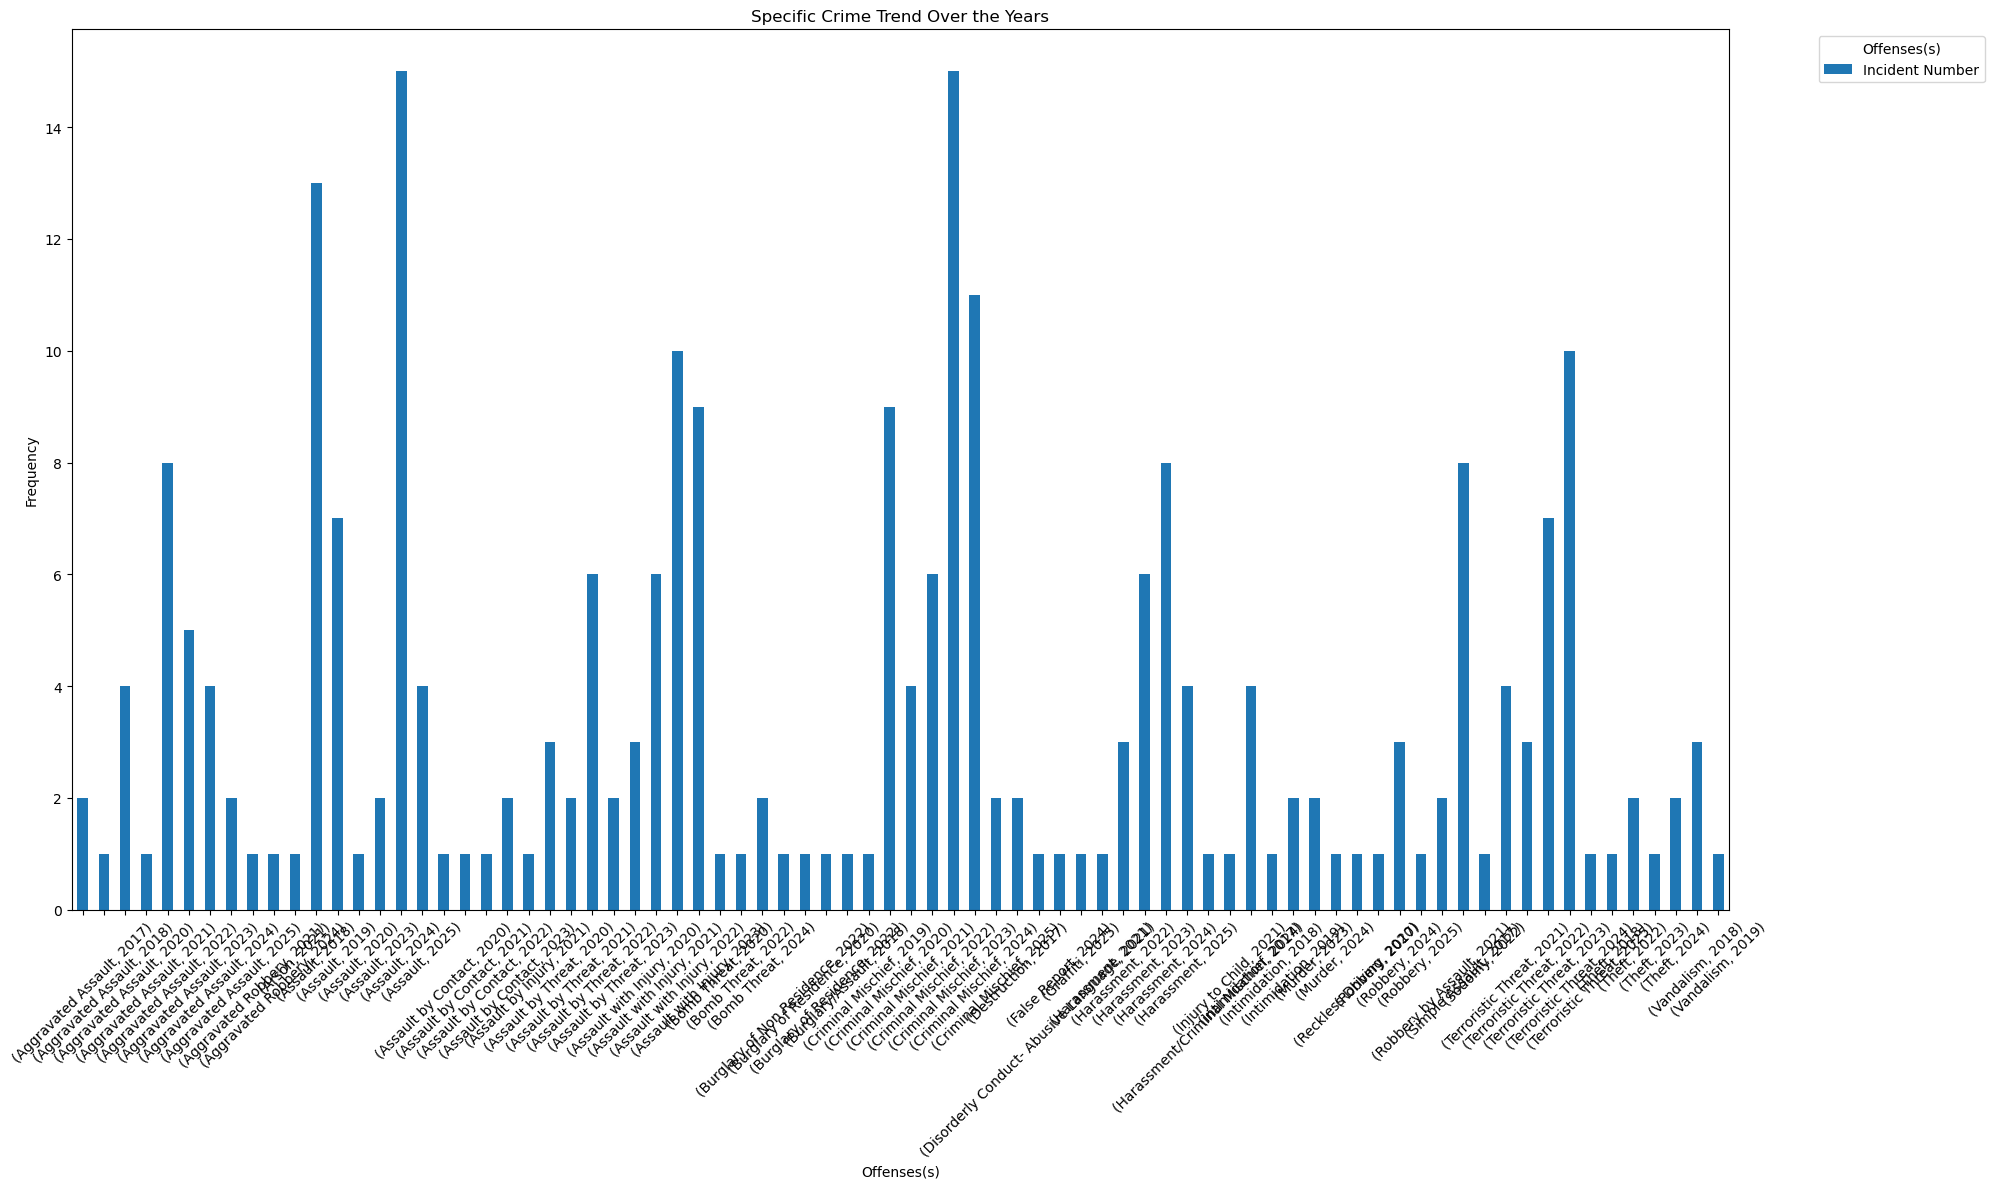

In [245]:
specific_crime_trend = df.groupby(["Offense(s)","Year"])["Incident Number"].count()
plt.figure(figsize = (20,12))
specific_crime_trend.plot(kind = "bar",xlabel = 'Offenses(s)', ylabel= 'Frequency', title = 'Specific Crime Trend Over the Years', stacked = True)
plt.xticks(rotation=45)
plt.legend(title="Offenses(s)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [123]:
specific_crime_trend

Offense(s)          Year
Aggravated Assault  2017    2
                    2018    1
                    2020    4
                    2021    1
                    2022    8
                           ..
Theft               2022    2
                    2023    1
                    2024    2
Vandalism           2018    3
                    2019    1
Name: Incident Number, Length: 78, dtype: int64

In [ ]:
###What is the distribution of victims by age (under 18 vs. over 18)?

In [137]:
df.head()

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District,Year,Month of incidence,Crime_month
0,1,2017-241137,01/01/2017 12:00:00 AM,Sun,0,1,0,1,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0,2017,1,Jan
1,2,2017-580344,02/01/2017 12:00:00 AM,Wed,0,1,0,1,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0,2017,2,Feb
2,3,2017-800291,03/21/2017 12:00:00 AM,Tue,0,0,0,0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0,2017,3,Mar
3,4,2017-1021534,04/12/2017 12:00:00 AM,Wed,0,0,0,0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0,2017,4,April
4,5,2017-1351550,05/15/2017 12:00:00 AM,Mon,1,0,1,2,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0,2017,5,May


In [149]:
df["Number of Victims under 18"] = pd.to_numeric(df["Number of Victims under 18"], errors='coerce')
under_18_victim_count = df[df["Number of Victims under 18"] > 0].shape[0]
under_18_victim_count

12

In [155]:
df['Number of Victims over 18'] = pd.to_numeric(df["Number of Victims over 18"], errors = 'coerce')
over_18_victim_count = df[df['Number of Victims over 18'] > 0].shape[0]
over_18_victim_count

248

In [161]:
distribution = [under_18_victim_count,over_18_victim_count]
distribution

[12, 248]

In [ ]:
##How often are offenders under 18 involved compared to adults?

In [185]:
df['Number of Offenders under 18'] = pd.to_numeric(df['Number of Offenders under 18'], errors = 'coerce')
offender_under_18 = df[df['Number of Offenders under 18'] > 0].shape[0]
offender_under_18 

15

In [187]:
df['Number of Offenders over 18'] = pd.to_numeric(df['Number of Offenders over 18'],errors = 'coerce')
offenders_over_18 = df[df['Number of Offenders over 18'] > 0 ].shape[0]
offenders_over_18 

201

In [189]:
total_offenders = (offender_under_18  + offenders_over_18)

In [191]:
percent_under_18_offender = (offender_under_18/total_offenders) * 100

In [193]:
percent_under_18_offender

6.944444444444445

In [195]:
"""Offenders Under 18 contribute 6.9% to the total number of offenders"""

'Offenders Under 18 contribute 6.9% to the total number of offenders'

In [ ]:
###What are the most common racial/ethnic groups of offenders?

In [203]:
common_race_of_offenders = df["Race/Ethnicity of Offenders"].value_counts().head(5)
common_race_of_offenders 

Race/Ethnicity of Offenders
White/Non-Hispanic                        70
Unknown                                   68
White/Hispanic                            35
Black or African American/Non-Hispanic    21
White/Unknown                             15
Name: count, dtype: int64

In [ ]:
##What are the most common bias motivations behind hate crimes?

In [211]:
top_bias_on_hate_crimes = df["Bias"].value_counts().head()
top_bias_on_hate_crimes

Bias
Anti-Black or African American    58
Anti-Gay (Male)                   55
Anti-Jewish                       35
Anti-Hispanic or Latino           17
Anti-White                        14
Name: count, dtype: int64

In [ ]:
##How have different types of bias-related hate crimes (e.g., Anti-Black, Anti-Jewish, Anti-Gay) changed over time?

In [213]:
df.head()

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District,Year,Month of incidence,Crime_month
0,1,2017-241137,01/01/2017 12:00:00 AM,Sun,0.0,1.0,0.0,1.0,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0,2017,1,Jan
1,2,2017-580344,02/01/2017 12:00:00 AM,Wed,0.0,1.0,0.0,1.0,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0,2017,2,Feb
2,3,2017-800291,03/21/2017 12:00:00 AM,Tue,0.0,0.0,0.0,0.0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0,2017,3,Mar
3,4,2017-1021534,04/12/2017 12:00:00 AM,Wed,0.0,0.0,0.0,0.0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0,2017,4,April
4,5,2017-1351550,05/15/2017 12:00:00 AM,Mon,1.0,0.0,1.0,2.0,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0,2017,5,May


In [221]:
yealy_bias = df.groupby(["Year","Bias"]).size().unstack(fill_value = 0)

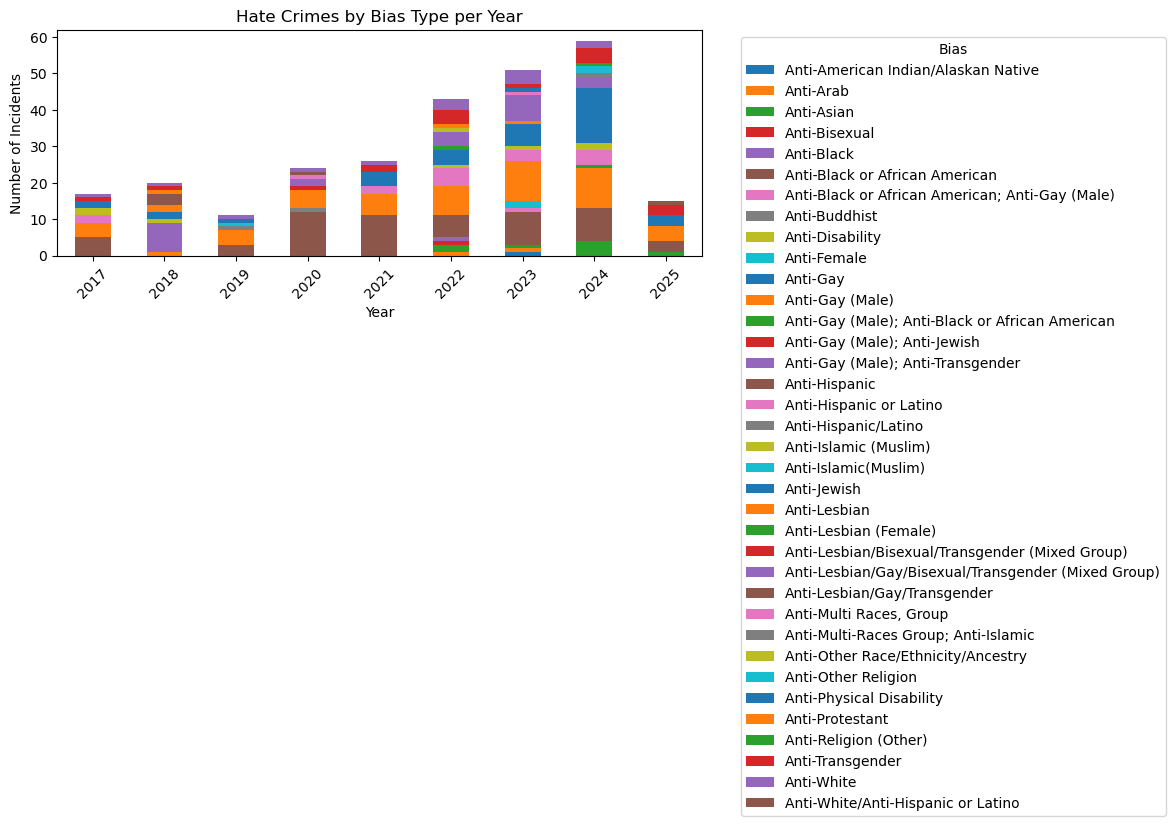

In [229]:
yealy_bias.plot(kind = "bar", stacked=True, figsize=(12, 6))
plt.title("Hate Crimes by Bias Type per Year")
plt.ylabel("Number of Incidents")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.legend(title="Bias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [247]:
df.head()

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District,Year,Month of incidence,Crime_month
0,1,2017-241137,01/01/2017 12:00:00 AM,Sun,0.0,1.0,0.0,1.0,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0,2017,1,Jan
1,2,2017-580344,02/01/2017 12:00:00 AM,Wed,0.0,1.0,0.0,1.0,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0,2017,2,Feb
2,3,2017-800291,03/21/2017 12:00:00 AM,Tue,0.0,0.0,0.0,0.0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0,2017,3,Mar
3,4,2017-1021534,04/12/2017 12:00:00 AM,Wed,0.0,0.0,0.0,0.0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0,2017,4,April
4,5,2017-1351550,05/15/2017 12:00:00 AM,Mon,1.0,0.0,1.0,2.0,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0,2017,5,May


In [ ]:
##Which ZIP codes or council districts report the most hate crimes?

In [253]:
most_crime_by_ZIPCode = df.groupby('Zip Code')["Incident Number"].count().idxmax()
most_crime_by_ZIPCode

78701.0

In [255]:
Most_crime_by_Council_disctrict = df.groupby("Council District")["Incident Number"].count().idxmax()
Most_crime_by_Council_disctrict

9.0

In [ ]:
##Are there clusters of incidents in certain APD sectors?

In [281]:
ADP_sector_incidents = df['APD Sector'].value_counts().sort_values(ascending = False)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21956\3341935117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= ADP_sector_incidents.index, y =ADP_sector_incidents.values,  palette="viridis")


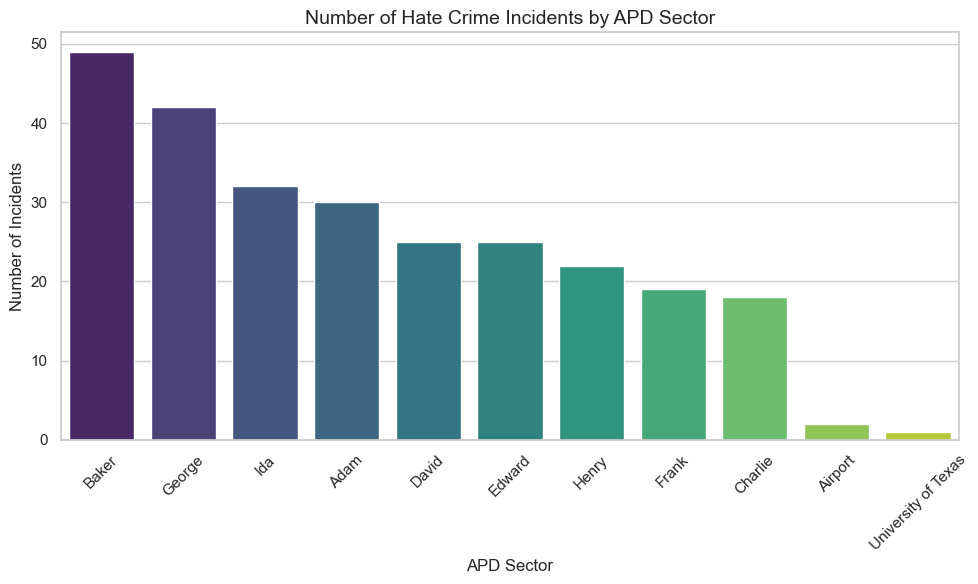

In [289]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x= ADP_sector_incidents.index, y =ADP_sector_incidents.values,  palette="viridis")
plt.xticks(rotation=45)
plt.title("Number of Hate Crime Incidents by APD Sector", fontsize=14)
plt.xlabel("APD Sector", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.tight_layout()

In [ ]:
##How does the type of bias vary by geographic location?

In [309]:
crosstab = pd.crosstab(df["Offense Location"], df["Bias"])
top_locations = df["Offense Location"].value_counts().nlargest(10).index
filtered_crosstab = crosstab.loc[top_locations]
filtered_crosstab

Bias,Anti-American Indian/Alaskan Native,Anti-Arab,Anti-Asian,Anti-Bisexual,Anti-Black,Anti-Black or African American,Anti-Black or African American; Anti-Gay (Male),Anti-Buddhist,Anti-Disability,Anti-Female,...,"Anti-Multi Races, Group",Anti-Multi-Races Group; Anti-Islamic,Anti-Other Race/Ethnicity/Ancestry,Anti-Other Religion,Anti-Physical Disability,Anti-Protestant,Anti-Religion (Other),Anti-Transgender,Anti-White,Anti-White/Anti-Hispanic or Latino
Offense Location,,,,,,,,,,,,,,,,,,,,,
Residence/Home,0,0,4,1,1,14,0,0,0,0,...,0,0,0,1,0,0,0,3,4,0
Hwy/Road/Alley/Street/Sidewalk,0,0,0,0,0,8,1,0,0,0,...,0,1,0,0,1,0,0,2,0,1
Streets/Highway/Road/Alley,0,0,0,0,0,10,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
Bar/Nightclub,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
Parking/Drop Lot/Garage,1,1,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Commercial/Office Building,0,0,0,0,0,3,0,0,0,0,...,1,0,0,0,0,0,0,0,2,0
Church/Synagogue/Temple/Mosque,0,0,1,0,0,0,0,1,0,0,...,0,0,0,1,0,1,1,0,0,0
Convenience Store,0,1,0,0,2,2,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
Park/Playground,0,0,0,0,1,2,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
###Which locations (e.g., street, residence, park) are most frequently involved in incidents?

In [299]:
df["Offense Location"].value_counts().sort_values(ascending = False)

Offense Location
Residence/Home                              66
Hwy/Road/Alley/Street/Sidewalk              35
Streets/Highway/Road/Alley                  20
Bar/Nightclub                               18
Parking/Drop Lot/Garage                     17
Commercial/Office Building                   9
Church/Synagogue/Temple/Mosque               9
Convenience Store                            7
Park/Playground                              7
Air/Bus/Train Terminal                       7
Highway/Road/Alley/Street/Sidewalk           6
Other/Unknown                                5
Parking Lot/Garage                           5
Restaurant                                   5
Highway/Road/Street                          4
Parking Lots/Garage                          4
School-Elementary/Secondary                  3
Parking Lot                                  2
Shopping Mall                                2
Grocery/Supermarket                          2
Specialty Store                            

In [ ]:
##Is there a relationship between offense location and type of bias?

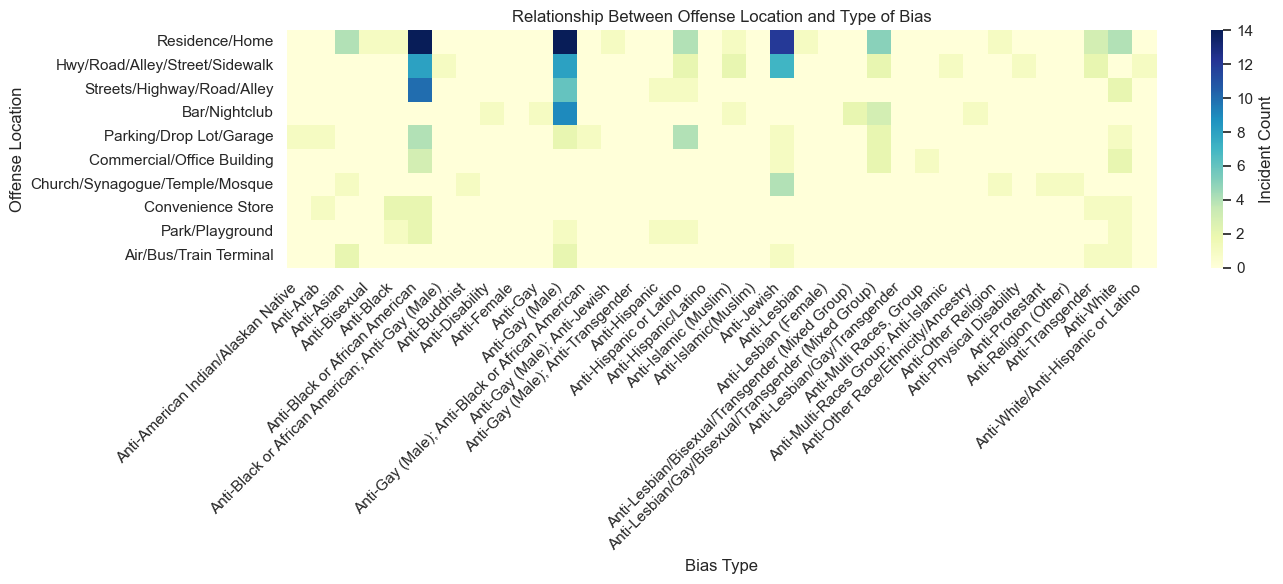

In [301]:
location_bias_crosstab = pd.crosstab(df["Offense Location"], df["Bias"])
top_locations = df["Offense Location"].value_counts().nlargest(10).index
filtered_crosstab = location_bias_crosstab.loc[top_locations]

plt.figure(figsize=(14, 6))
sns.heatmap(filtered_crosstab, cmap="YlGnBu", annot=False, fmt="d", cbar_kws={'label': 'Incident Count'})
plt.title("Relationship Between Offense Location and Type of Bias")
plt.xlabel("Bias Type")
plt.ylabel("Offense Location")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [311]:
##What are the most common types of offenses involved in hate crimes?

In [321]:
top_offenses = df["Offense(s)"].value_counts().sort_values(ascending=False).head(10)
top_offenses

Offense(s)
Criminal Mischief      48
Assault                42
Assault with Injury    28
Aggravated Assault     27
Terroristic Threat     25
Harassment             22
Assault by Threat      13
Simple Assault          8
Intimidation            7
Theft                   6
Name: count, dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21956\1411869288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = top_offenses.index, x = top_offenses.values, palette = 'magma')


Text(0.5, 1.0, 'Most Common Offenses')

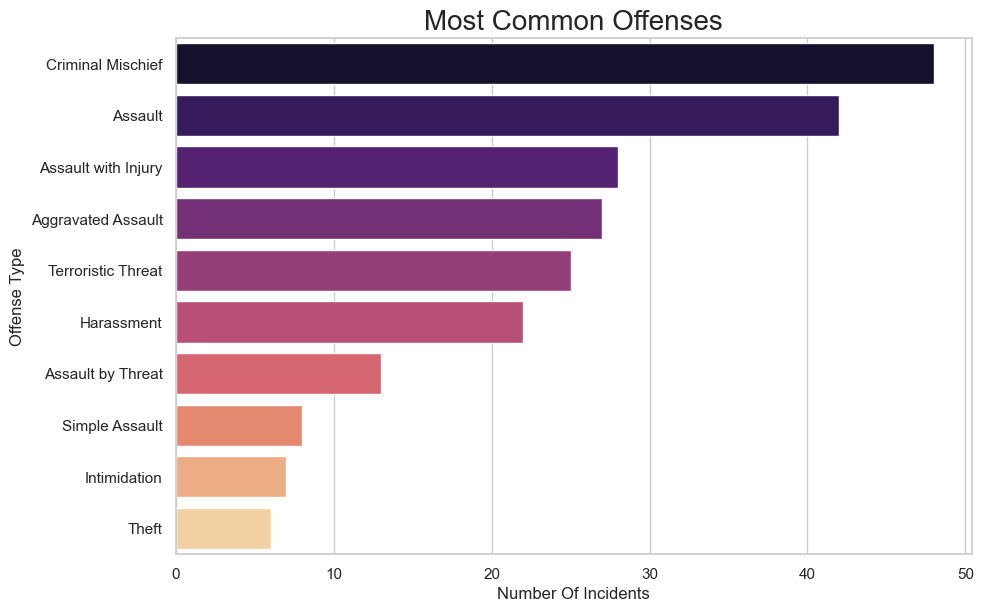

In [335]:
plt.figure(figsize =( 10,6))
sns.barplot(y = top_offenses.index, x = top_offenses.values, palette = 'magma')
plt.xlabel("Number Of Incidents")
plt.ylabel("Offense Type")
plt.tight_layout()
plt.title("Most Common Offenses", fontsize = 20)